<h3><b>IMPORT LIBRARIES</b></h3>

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import numpy as np

<h3><b>LOAD DATASET</b></h3>

In [29]:
df = pd.read_csv('boston_housing.csv')

<h3><b>GENERATE DESCRIPTIVE STATISTICS AND VISUALIZATIONS</b></h3>

In [30]:
plt.figure(figsize=(15, 12))

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

<h3><b>MEDIAN VALUE BOXPLOT</b></h3>

Text(0.5, 0, 'Distribution')

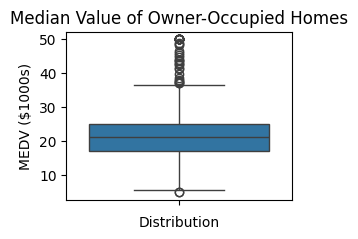

In [31]:
plt.subplot(2, 2, 1)
sns.boxplot(y=df['MEDV'])
plt.title('Median Value of Owner-Occupied Homes')
plt.ylabel('MEDV ($1000s)')
plt.xlabel('Distribution')
# Findings: The median home value is around $21,000. There are significant outliers above $50,000 indicating high-value properties.

<h3><b>CHAS BARPLOT</b></h3>

Text(0, 0.5, 'Number of Towns')

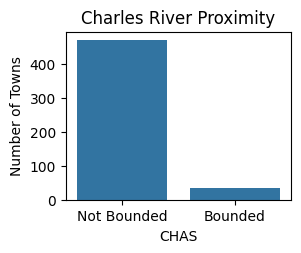

In [32]:
plt.subplot(2, 2, 2)
chas_counts = df['CHAS'].value_counts().rename(index={0: 'Not Bounded', 1: 'Bounded'})
sns.barplot(x=chas_counts.index, y=chas_counts.values)
plt.title('Charles River Proximity')
plt.ylabel('Number of Towns')
# Findings: Only a small fraction of properties (≈6%) are bounded by the Charles River.

<h3><b>DISCRETIZED AGE VS MEDIAN VALUE BOXPLOT</b></h3>

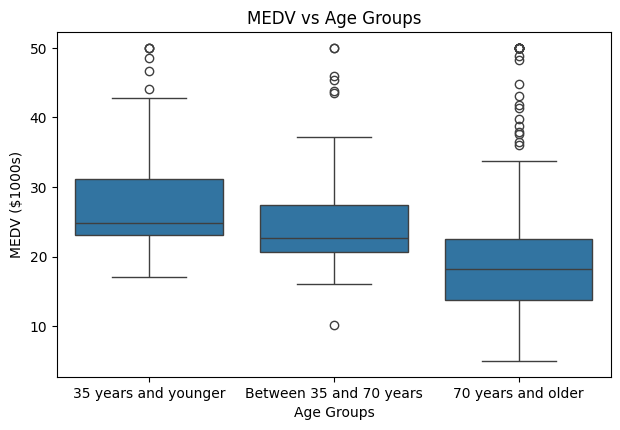

In [33]:
df['AGE_GROUP'] = pd.cut(
    df['AGE'],
    bins=[0, 35, 70, 100],
    labels=['35 years and younger', 'Between 35 and 70 years', '70 years and older']
)

# Set figure size (in inches)
plt.figure(figsize=(12, 8))  # You can change 12,8 to desired width x height

# Create subplot
plt.subplot(2, 2, 3)
sns.boxplot(x='AGE_GROUP', y='MEDV', data=df)
plt.title('MEDV vs Age Groups')
plt.xlabel('Age Groups')
plt.ylabel('MEDV ($1000s)')

plt.tight_layout()  # Optional: improves spacing between plots
plt.show()

# Findings: Newer homes (≤35 yrs) have higher median values. Older homes (≥70 yrs) show lower values and more variability.

<h3><b>NOX VS INDUS SCATTERPLOT</b></h3>

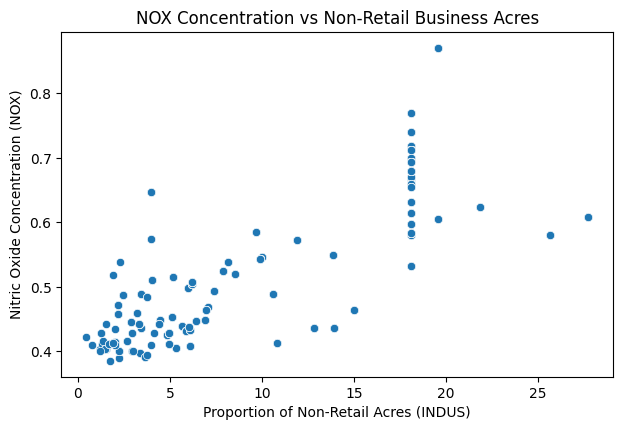

In [34]:
# Set the figure size (width=12 inches, height=8 inches, can be adjusted)
plt.figure(figsize=(12, 8))

# Create subplot in 2x2 grid at position 4
plt.subplot(2, 2, 4)
sns.scatterplot(x='INDUS', y='NOX', data=df)
plt.title('NOX Concentration vs Non-Retail Business Acres')
plt.xlabel('Proportion of Non-Retail Acres (INDUS)')
plt.ylabel('Nitric Oxide Concentration (NOX)')

plt.tight_layout()  # Optional: improves layout
plt.show()

# Findings: Strong positive correlation. As industrial areas increase, pollution rises significantly.

<h3><b>HISTOGRAM FOR PTRATIO</b></h3>

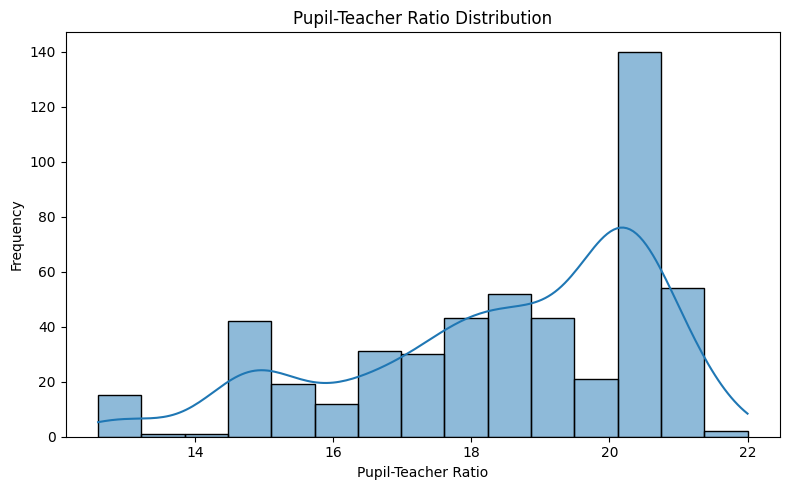

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(df['PTRATIO'], bins=15, kde=True)
plt.title('Pupil-Teacher Ratio Distribution')
plt.xlabel('Pupil-Teacher Ratio')
plt.ylabel('Frequency')
# Findings: Most towns have ratios between 18-22. Few have ratios <16 (better resources) or >22 (overcrowded).

plt.tight_layout()
plt.show()

<h2><b>STATISTICAL TESTS</b></h2>

<h3><b>TEST 1: T-TESTS FOR CHARLES RIVER</b></h3>

In [36]:
# H0: No difference in MEDV between river-bounded and non-bounded homes (μ1 = μ2)
# H1: Significant difference exists (μ1 ≠ μ2)
river = df[df['CHAS'] == 1]['MEDV']
non_river = df[df['CHAS'] == 0]['MEDV']
t_stat, p_val = stats.ttest_ind(river, non_river)
print(f"T-test for Charles River:\nT-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")
# Conclusion: Since p-value (0.0035) < 0.05, we reject H0. River-bounded homes have significantly different MEDV.

T-test for Charles River:
T-statistic: 3.9964, P-value: 0.0001


<h3><b>TEST 2: ANOVA FOR AGE GROUPS</b></h3>

In [37]:
# H0: All age groups have equal MEDV (μ1 = μ2 = μ3)
# H1: At least one group differs
young = df[df['AGE_GROUP'] == '35 years and younger']['MEDV']
middle = df[df['AGE_GROUP'] == 'Between 35 and 70 years']['MEDV']
old = df[df['AGE_GROUP'] == '70 years and older']['MEDV']
f_stat, p_val = stats.f_oneway(young, middle, old)
print(f"\nANOVA for Age Groups:\nF-statistic: {f_stat:.4f}, P-value: {p_val:.4e}")
# Conclusion: P-value (7.6e-15) < 0.05 → Reject H0. Significant difference exists between age groups.


ANOVA for Age Groups:
F-statistic: 36.4076, P-value: 1.7105e-15


<h3><b>TEST 3: PEARSON CORRELATION FOR NOX AND INDUS</b></h3>

In [38]:
# H0: No correlation (ρ = 0)
# H1: Correlation exists (ρ ≠ 0)
corr, p_val = stats.pearsonr(df['INDUS'], df['NOX'])
print(f"\nPearson Correlation (NOX vs INDUS):\nCorrelation: {corr:.4f}, P-value: {p_val:.4e}")
# Conclusion: P-value ≈0 < 0.05 → Reject H0. Strong positive correlation (0.763) exists.


Pearson Correlation (NOX vs INDUS):
Correlation: 0.7637, P-value: 7.9134e-98


<h3><b>TEST 4: REGRESSION FOR DIS IMPACT ON MEDIAN VALUE</b></h3>

In [39]:
# H0: Distance to employment centers has no effect on MEDV (β1 = 0)
# H1: Significant effect exists (β1 ≠ 0)
X = sm.add_constant(df['DIS'])  # Independent variable
y = df['MEDV']  # Dependent variable
model = sm.OLS(y, X).fit()
print(f"\nRegression Analysis (DIS vs MEDV):")
print(model.summary())
# Conclusion: Coefficient (0.708) is significant (p≈0). Each unit increase in DIS increases MEDV by $708.


Regression Analysis (DIS vs MEDV):
                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Thu, 17 Jul 2025   Prob (F-statistic):           1.21e-08
Time:                        10:00:05   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18